# EDA and Training Notebook

This notebook documents the dataset exploration and model training workflow for the heart disease project.

Shape: (303, 14)
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


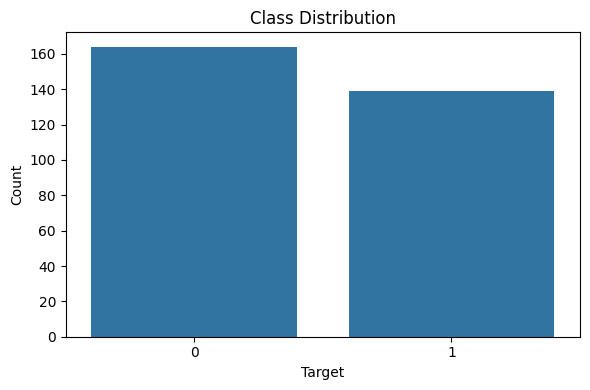

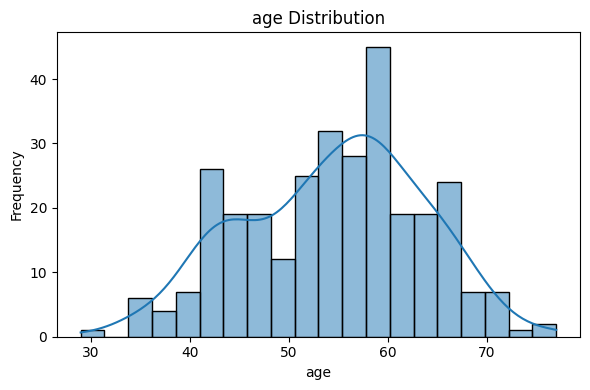

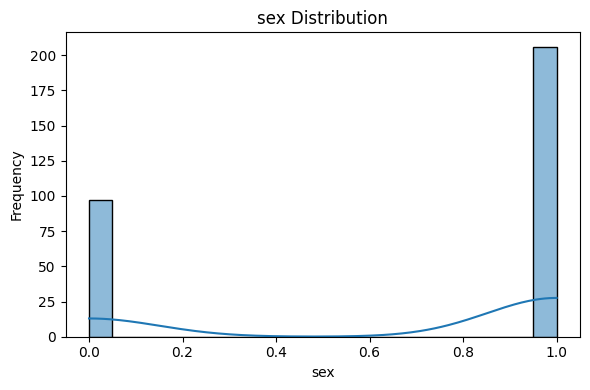

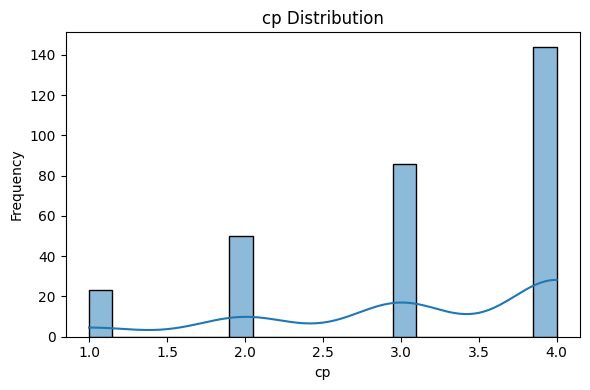

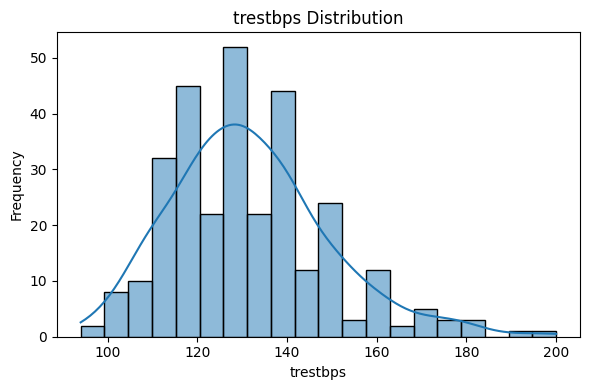

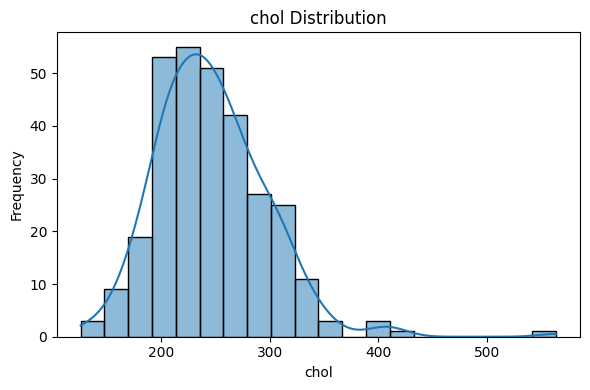

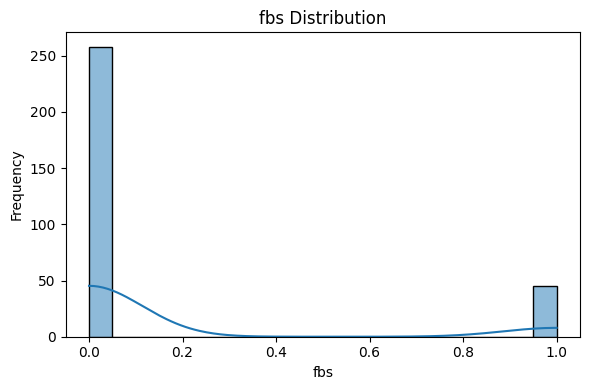

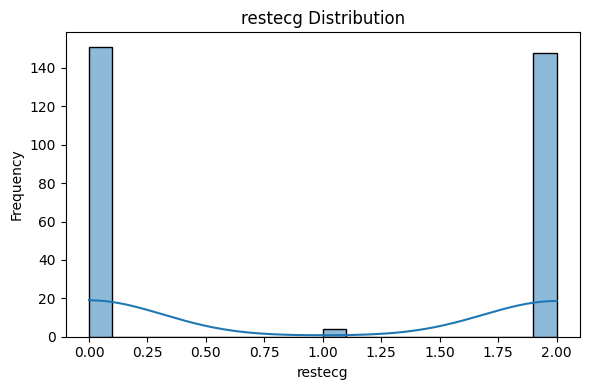

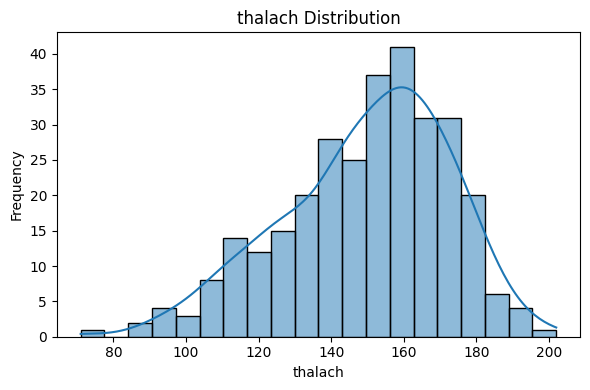

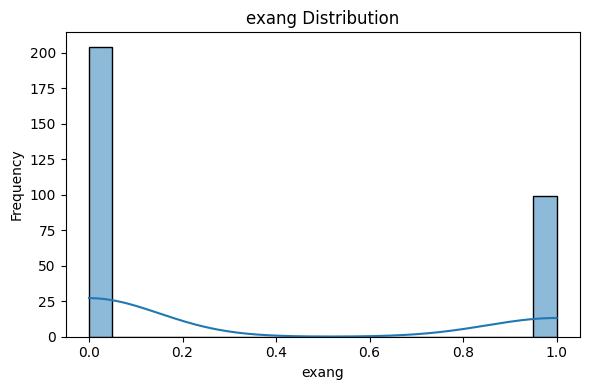

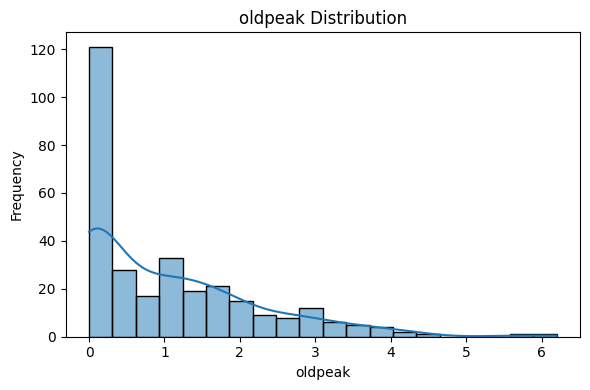

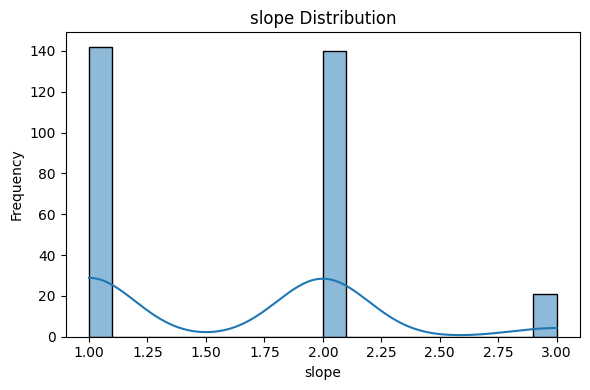

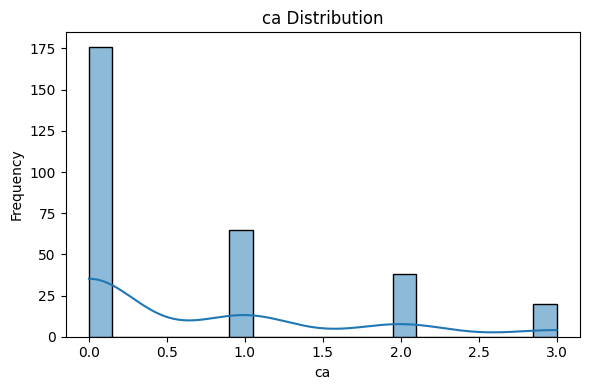

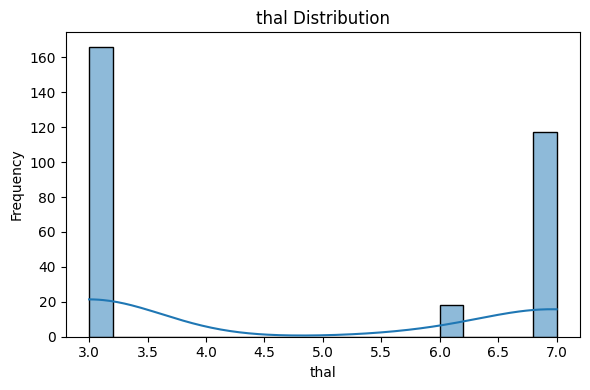

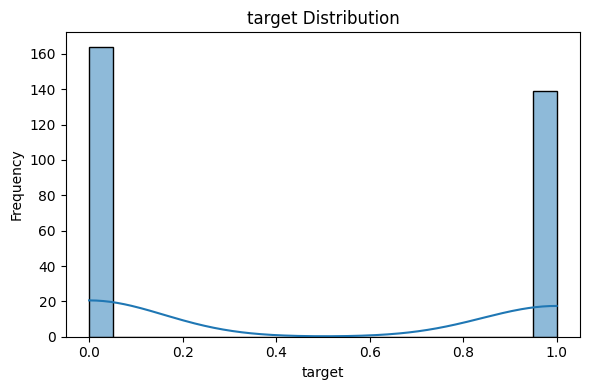

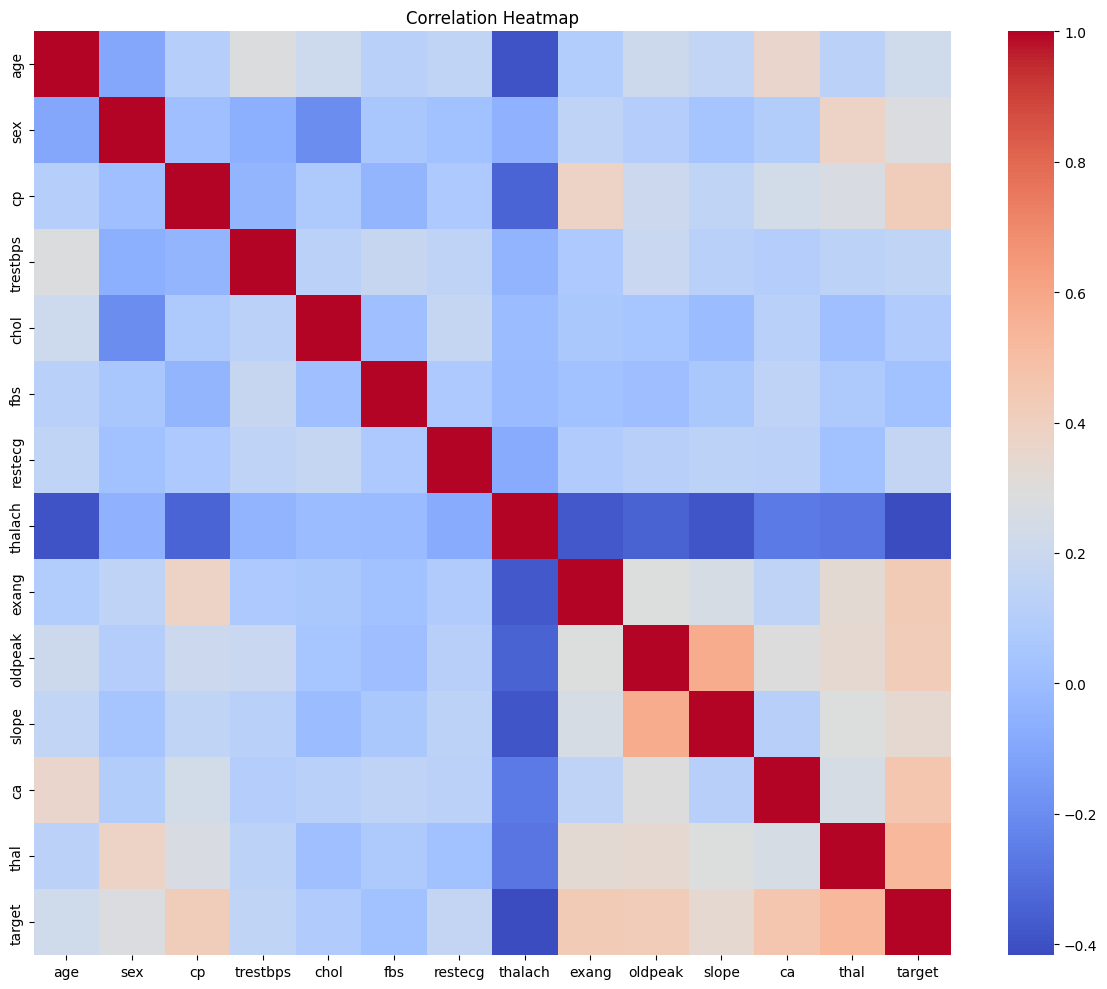

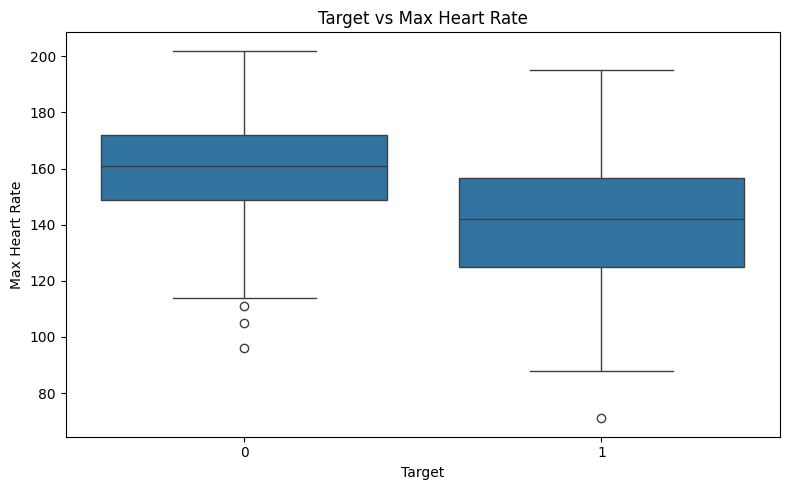

Model comparison summary:
- logistic_regression: accuracy=0.869, precision=0.812, recall=0.929, roc_auc=0.951, cv_accuracy_mean=0.826, cv_accuracy_std=0.017
- random_forest: accuracy=0.902, precision=0.844, recall=0.964, roc_auc=0.955, cv_accuracy_mean=0.814, cv_accuracy_std=0.014
Selected model: random_forest
Models were trained with median imputation, standard scaling, and 5-fold stratified cross-validation.
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3  

In [10]:
import os
import sys
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Make the project root importable when the notebook is launched from notebooks/ or elsewhere.
try:
    notebook_dir = Path(__file__).resolve().parent
except NameError:
    notebook_dir = Path.cwd()

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, notebook_dir, notebook_dir.parent]
project_root = None
for candidate in candidates:
    if (candidate / "src").exists():
        project_root = candidate
        break

if project_root is None:
    project_root = Path.cwd()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

import src.models.model_comparison as model_comparison_module
model_comparison_module = importlib.reload(model_comparison_module)
compare_models = model_comparison_module.compare_models

from src.data.load_data import load_dataset

# Load data

df = load_dataset(path='data/heart_disease.csv')

# Basic data overview
print('Shape:', df.shape)
print(df.dtypes)
print('\nMissing values:\n', df.isnull().sum())

# 1) Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title('Class Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2) Histograms for numeric features
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# 3) Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4) Feature relationship analysis
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='target', y='thalach')
plt.title('Target vs Max Heart Rate')
plt.xlabel('Target')
plt.ylabel('Max Heart Rate')
plt.tight_layout()
plt.show()

# 5) Model comparison and selection
comparison = compare_models(df)
print('Model comparison summary:')
for name, metrics in comparison['results'].items():
    print(f"- {name}: accuracy={metrics['accuracy']:.3f}, precision={metrics['precision']:.3f}, recall={metrics['recall']:.3f}, roc_auc={metrics['roc_auc']:.3f}, cv_accuracy_mean={metrics['cv_accuracy_mean']:.3f}, cv_accuracy_std={metrics['cv_accuracy_std']:.3f}")
print(f"Selected model: {comparison['best_model']}")
print(comparison['tuning_note'])

print(df.head())